## <font color="#117A65"><b>직원 이탈 예측</b></font>

### <font color="#5D6D7E"><b>목적</b></font>
<b>직원 이탈 가능성이 높은 인원을 사전에 예측</b>하여  
조직의 인사관리 전략에 활용할 수 있도록  
직원 특성 데이터를 기반으로 예측 모델을 구축합니다.  

### <font color="#5D6D7E"><b>배경 시나리오</b></font>  
<b>B사</b>는 최근 퇴사율이 증가하면서 인재 유출에 대한 우려가 커지고 있습니다.  
회사는 직원들이 어떤 특성을 보일 때 이탈 가능성이 높은지를 파악하고,  
이를 위해 다양한 직원 정보를 수집하고,
<b>이직 여부</b>를 예측하는 모델을 구축하고자 합니다.

---

### 📊 데이터 설명
**파일 이름:** `employee_churn.csv`

| 컬럼명               | 설명                                                                 |
|----------------------|----------------------------------------------------------------------|
| `years_experience`   | 근속 연수 (년 단위, 연속형)                                          |
| `salary`             | 급여 수준                                       |
| `education_level`    | 교육 수준 (예: `High School`, `Bachelor`, `Master`, `PhD` 등)        |
| `department`         | 부서명 (예: `Sales`, `R&D`, `HR`, `Finance`, `Engineering` 등)       |
| `overtime`           | 초과근무 여부 (Y/N)                                |
| `job_satisfaction`   | 직무 만족도 (1~5 점 척도)                                            |
| `work_life_balance`  | 일과 삶의 균형 만족도 (1~5 점 척도)                                 |
| `attrition`          | **이직 여부 (`1`: 이직함, `0`: 재직 중)** ← ⭐ **예측 대상 변수**

---


## [문제 1] 라이브러리 불러오기

🎯 목표  
데이터 분석을 위해 pandas, numpy, seaborn, matplotlib 라이브러리를 불러옵니다.

📑 조건  
- pandas를 `pd`, numpy를 `np`, seaborn을 `sns`, matplotlib.pyplot을 `plt`로 임포트하세요.


In [1]:
# 여기에 답안코드를 작성하세요.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## [문제 2] 데이터 불러오기

🖋 상황 설명  
`employee_churn.csv` 파일을 불러오려 합니다.

🎯 목표
- 파일을 읽어 churn_df라는 이름의 데이터프레임으로 저장하세요.

📑 조건
- 파일명: employee_churn.csv

In [3]:
# 여기에 답안코드를 작성하세요.
churn_df = pd.read_csv('employee_churn.csv')
churn_df

,years_experience,salary,education_level,department,overtime,job_satisfaction,work_life_balance,attrition
0,15.0,54.6,master,finance,N,3,4,1
1,5.6,116.6,bachelor,hr,N,3,2,1
2,11.0,32.2,phd,hr,N,4,2,1
3,16.2,82.2,phd,sales,Y,1,3,1
4,12.4,97.7,high_school,engineering,N,2,3,1
...,...,...,...,...,...,...,...,...
1095,11.6,117.4,high_school,hr,Y,2,2,0
1096,18.0,58.3,high_school,marketing,N,2,4,0
1097,15.9,39.8,master,finance,Y,3,3,0
1098,2.1,NaN,bachelor,engineering,Y,3,4,0


## [문제 3] 데이터 확인

🖋 상황 설명  
work_life_balance(일과 삶의 균형 만족도)와 department(부서명)에 따른 overtime(초과근무)를 시각화를 통해 보고자합니다.

🎯 목표
- seaborn의 barplot()을 이용하여 그래프를 만드세요.
- x= 'department', y='work_life_balance', hue='overtime'
- 4지 선다의 문제를 보고 정답을 답03 변수에 저장하세요.

다음 중 부서(department)와 초과근무 여부(overtime)에 따른 work_life_balance 평균 비교 결과에 대한 설명으로 가장 적절한 것은 무엇인가?

1. 모든 부서에서 초과근무를 하지 않는 직원들의 work_life_balance가 더 높다.
2. finance 부서는 초과근무를 하는 직원의 work_life_balance가 더 높다.
3. engineering 부서는 초과근무 여부와 관계없이 work_life_balance에 차이가 없다.
4. sales 부서는 초과근무를 하는 직원의 work_life_balance가 더 높다.

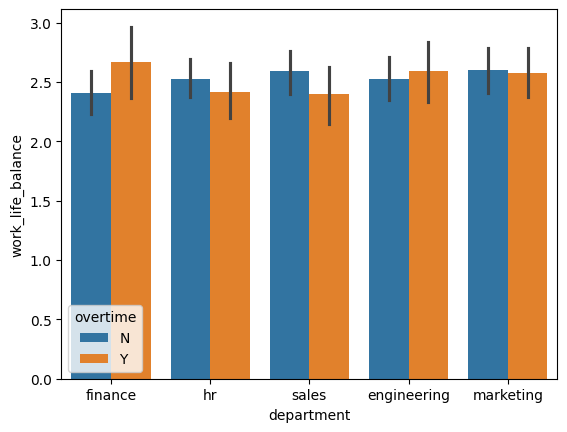

In [4]:
# 여기에 답안코드를 작성하세요.
sns.barplot(data=churn_df, x= 'department', y='work_life_balance', hue='overtime')
답03 = 2

## [문제 4] 결측치 처리

🖋 상황 설명  
결측치가 있는 컬럼을 찾고, 결측치가 존재하는 행을 지우고자 합니다.

🎯 목표
- 결측치를 찾는 코드를 작성하고, 결측치가 존재하는 컬럼명을 답04 변수에 저장하세요(예 : 답04 = 'overtime, attrition')
- 결측치가 존재하는 행을 지우고 처리한 데이터를 pre_df 변수에 저장하세요.

📑 조건
- 저장된 pre_df 변수는 reset_index()를 이용하여 index를 초기화 하세요.
- drop = True, inplace = True

In [5]:
# 여기에 답안코드를 작성하세요.
churn_df.isna().sum()

답04 = 'years_experience, salary'
pre_df = churn_df.dropna(subset=['years_experience', 'salary'])
pre_df.reset_index(drop=True, inplace=True)
pre_df

,years_experience,salary,education_level,department,overtime,job_satisfaction,work_life_balance,attrition
0,15.0,54.6,master,finance,N,3,4,1
1,5.6,116.6,bachelor,hr,N,3,2,1
2,11.0,32.2,phd,hr,N,4,2,1
3,16.2,82.2,phd,sales,Y,1,3,1
4,12.4,97.7,high_school,engineering,N,2,3,1
...,...,...,...,...,...,...,...,...
1009,19.2,113.5,bachelor,engineering,N,1,1,1
1010,11.6,117.4,high_school,hr,Y,2,2,0
1011,18.0,58.3,high_school,marketing,N,2,4,0
1012,15.9,39.8,master,finance,Y,3,3,0


## [문제 5] Groupby를 이용한 데이터 확인

🖋 상황 설명  
부서별로 직원들의 직무 만족도(job_satisfaction) 평균을 분석하여, 직원 만족도가 높은 부서를 찾고자 합니다.

🎯 목표
- groupby를 이용하여 각 부서(department)의 평균 직무 만족도를 계산하여, 가장 만족도가 높은 부서를 찾으세요.  <br>(대상 데이터프레임 : pre_df)
- 문제를 보고 만족도가 높은 부서를 답05 변수에 저장하세요.
  
📑 문제
1. Sales
2. HR
3. Engineering
4. Marketing
5. Engineering

In [7]:
# 여기에 답안코드를 작성하세요.
pre_df.groupby('department')['job_satisfaction'].mean()
답05 = 4

## [문제 6] crosstab을 이용한 데이터 확인

🖋 상황 설명  
부서별로 이직률(Attrition 비율)을 분석하고자 합니다.  
이를 위해 pandas의 crosstab() 함수를 사용하여 부서(department)별 이직 여부(attrition) 비율을 계산합니다.

🎯 목표
- 각 부서별로 이직률과 재직률을 비율(%)로 확인합니다.
- 가장 attrition(이직여부)가 높은 부서를 답06 변수에 저장하세요(예 : 답06 = 'hr')

📑 조건
- 대상 데이터프레임 : pre_df
- normalize = 'index'
- round()를 사용하여 소수점 둘째자리까지 출력하세요.

In [8]:
# 여기에 답안코드를 작성하세요.
print(pd.crosstab(pre_df['department'], pre_df['attrition'], normalize='index').round(2))
답06 = 'engineering'

attrition       0     1
department             
engineering  0.61  0.39
finance      0.67  0.33
hr           0.66  0.34
marketing    0.69  0.31
sales        0.73  0.27


## [문제 7] 범주형 변수 인코딩

🖋 상황 설명  
범주형 변수들을 인코딩 합니다.

🎯 목표
- department 변수는 원핫 인코딩 진행
- overtime은 np.where을 이용하여 Y는 1로 N은 0으로 변경

[사전 실행 지시사항]
- 아래 셀을 실행하여 education_level에 대한 인코딩을 진행해 주세요.

In [9]:
edu_map = {
    'high_school': 0,
    'bachelor': 1,
    'master': 2,
    'phd': 3
}
pre_df['education_level'] = pre_df['education_level'].map(edu_map)


/tmp/ipython-input-3839330536.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pre_df['education_level'] = pre_df['education_level'].map(edu_map)


📑 조건
- 대상 데이터프레임 : pre_df
- 원핫 인코딩은 drop_first = True 옵션 사용
- 처리된 데이터는 encoding_df 변수에 저장

In [10]:
# 여기에 답안코드를 작성하세요.
encoding_df = pd.get_dummies(data=pre_df, columns=['department'], drop_first=True)
encoding_df['overtime'] = np.where(encoding_df['overtime'] == 'Y', 1, 0)
encoding_df

,years_experience,salary,education_level,overtime,job_satisfaction,work_life_balance,attrition,department_finance,department_hr,department_marketing,department_sales
0,15.0,54.6,2,0,3,4,1,True,False,False,False
1,5.6,116.6,1,0,3,2,1,False,True,False,False
2,11.0,32.2,3,0,4,2,1,False,True,False,False
3,16.2,82.2,3,1,1,3,1,False,False,False,True
4,12.4,97.7,0,0,2,3,1,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
1009,19.2,113.5,1,0,1,1,1,False,False,False,False
1010,11.6,117.4,0,1,2,2,0,False,True,False,False
1011,18.0,58.3,0,0,2,4,0,False,False,True,False
1012,15.9,39.8,2,1,3,3,0,True,False,False,False


## [문제 8] feature/target 분리

🖋 상황 설명  
모델 학습을 위해 X, y를 분리합니다.
<br> (대상 데이터프레임 : encoding_df)

🎯 목표
- X = attrition 제외 전부
- y = attrition

In [12]:
# 여기에 답안코드를 작성하세요.
X = encoding_df.drop(columns='attrition')
y = encoding_df['attrition']

## [문제 9] train/test 데이터 분리

🖋 상황 설명  
모델 학습 및 평가를 위해 데이터를 분리합니다.

🎯 목표
- 데이터셋을 분리하기 위해 train_test_split을 import하세요.
- 훈련 데이터 셋 = X_train, y_train
- 검증 데이터 셋 = X_valid, y_valid
- random_state=42
- 훈련 데이터셋과 검증 데이터셋의 비율은 8:2

In [13]:
# 여기에 답안코드를 작성하세요.
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

## [문제 10] 데이터 표준화

🖋 상황 설명  
데이터 스케일링을 통해 모델 학습의 성능을 높입니다.

[사전 실행 지시사항]
- 아래 셀을 실행하여 StandardScaler를 불러오세요.

In [14]:
from sklearn.preprocessing import StandardScaler

📑 조건  
- StandardScaler를 이용해 Feature 데이터를 스케일링하세요.
- X_train은 fit_tranform을 이용하여 X_train 변수에 저장
- X_valid는 transform을 이용하여 X_test의 변수에 저장


In [15]:
# 여기에 답안코드를 작성하세요.
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_valid)

## [문제 11] LightGBM 모델 학습

🖋 상황 설명  
LightGBM 모델을 이용하여 학습합니다.

⚙ 주어진 코드

In [16]:
from lightgbm import LGBMClassifier


📑 조건  
- LGBMClassifier를 사용해 attrition을 예측하는 모델을 학습하세요.
- LGBM모델을 lgbmc변수에 저장하세요.
- n_estimators=100, max_depth=6, learning_rate = 0.01, random_state=42
- 훈련은 스케일링 처리된 데이터를 사용해 주세요.

In [ ]:
# 여기에 답안코드를 작성하세요.
lgbmc = LGBMClassifier(n_estimators=100, learning_rate=0.01, max_depth=6, random_state=42)

lgbmc.fit(X_train, y_train)

## [문제 12] XGBoost 모델 학습

🎯 목표  
XGBoost 모델을 학습합니다.

[사전 실행 지시사항]
- 아래 셀을 실행하여 XGBClassifier를 불러오세요.

In [18]:
from xgboost import XGBClassifier

📑 조건  

- XGBClassifier를 사용해 leave_yn을 예측하는 모델을 학습하세요.
- XGBoost모델을 xgbc변수에 저장하세요.
- n_estimators=200, max_depth=8, learning_rate=0.1, random_state=42
- 훈련은 스케일링 처리된 데이터를 사용하여 주세요.

In [21]:
# 여기에 답안코드를 작성하세요.
xgbc = XGBClassifier(n_estimators = 200, max_depth = 8, learning_rate = 0.1, random_state = 42)
xgbc.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

## [문제 13] 모델 성능 비교

🖋 상황 설명  
모델 예측 성능을 비교합니다.

🎯 목표
- accuracy_score, f1_score 출력


[사전 실행 지시사항]
- 아래 셀을 실행하여 accuracy_score와 f1-score를 불러오세요.

In [22]:
from sklearn.metrics import accuracy_score, f1_score

📑 조건  
- lightGBM의 predict를 이용하여 검증 데이터를 예측하고, 예측된 데이터는 lgbmc_predict변수에 저장하여 주세요.
- xgboost의 predict를 이용하여 검증 데이터를 예측하고, 예측된 데이터는 xgbc_predict변수에 저장하여 주세요.
- 각 모델별 정확도와 f1-score를 출력

In [23]:
# 여기에 답안코드를 작성하세요.
lgbmc_predict = lgbmc.predict(X_valid)
xgbc_predict = xgbc.predict(X_valid)

print("LightGBM")
print("Accuracy:", accuracy_score(y_valid, lgbmc_predict))
print("F1 Score:", f1_score(y_valid, lgbmc_predict))

print("XGBoost")
print("Accuracy:", accuracy_score(y_valid, xgbc_predict))
print("F1 Score:", f1_score(y_valid, xgbc_predict))

LightGBM
Accuracy: 0.5665024630541872
F1 Score: 0.22807017543859648
XGBoost
Accuracy: 0.6108374384236454
F1 Score: 0.16842105263157894


## [문제 14] 딥러닝 모델 설계 및 학습

🖋 상황 설명  
딥러닝 모델로 이직 여부를 예측합니다.

🎯 목표
  ##### **모델 구조**
  - Dense(64, selu) → BatchNormalization  
  - Dense(32, selu) → BatchNormalization  
  - Dense(16, selu)  
  - Dense(2, softmax)  


optimizer: adam, loss: categorical_crossentropy, metric: accuracy  
epochs=50, batch_size=32

⚙ 주어진 코드

In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(10)
y_train = to_categorical(y_train, num_classes=2)
y_valid = to_categorical(y_valid, num_classes=2)

In [25]:
# 여기에 답안코드를 작성하세요.
model = Sequential()
model.add(Dense(64, activation='selu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dense(32, activation='selu'))
model.add(BatchNormalization())
model.add(Dense(16, activation='selu'))
model.add(Dense(2, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4836 - loss: 0.8459
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6248 - loss: 0.6655
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6745 - loss: 0.6348
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6932 - loss: 0.6218
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6966 - loss: 0.6124
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6928 - loss: 0.6052
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6973 - loss: 0.5999
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7016 - loss: 0.5951
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7064 - loss: 0.5909
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7134 - loss: 0.5867
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7187 - loss: 0.5828
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7173 - lo